-1.0 1.0
-1.0 1.0
-1.0 1.0
-1.0 1.0
-1.0 1.0
-1.0 1.0


<Axes: title={'center': 'Z Slice'}>

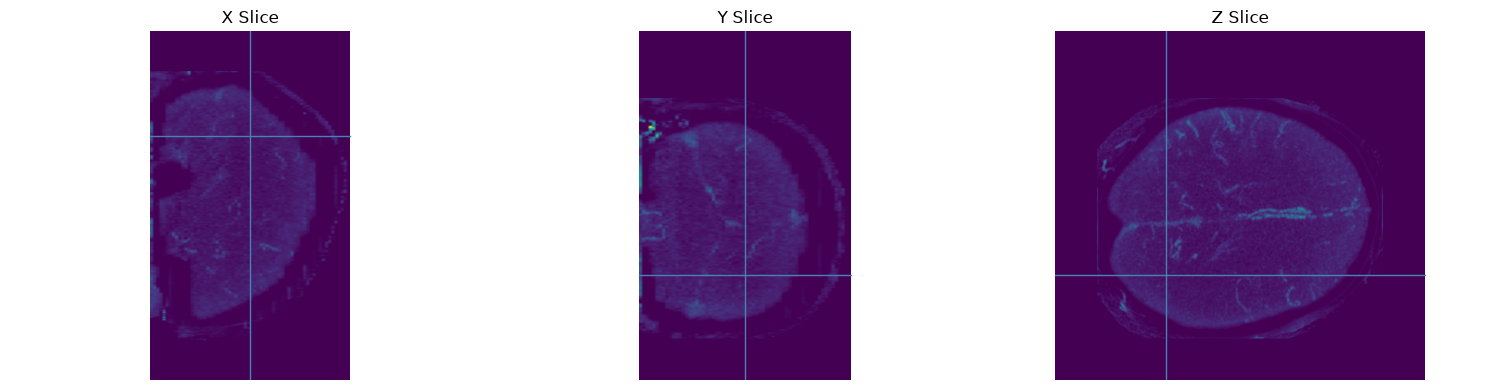

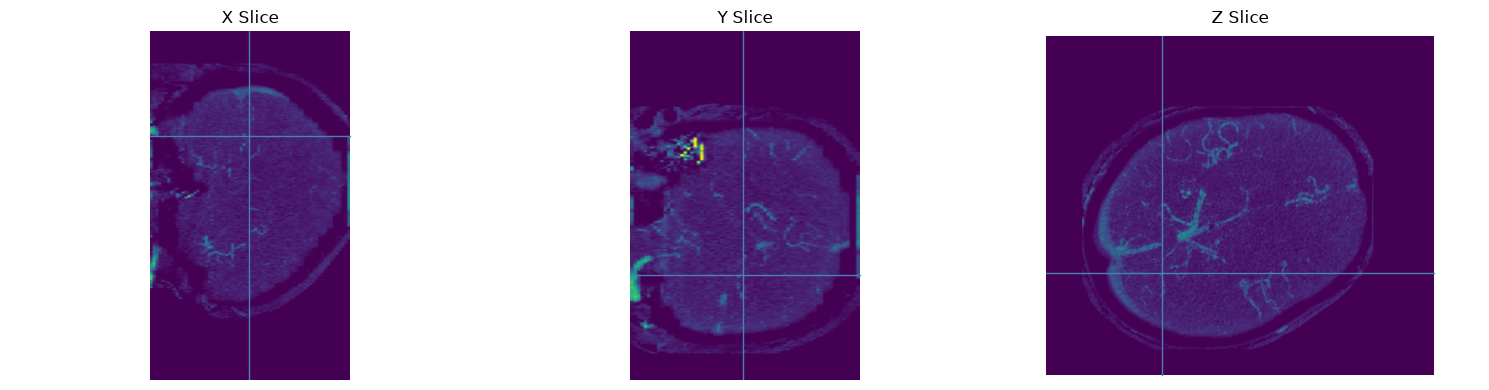

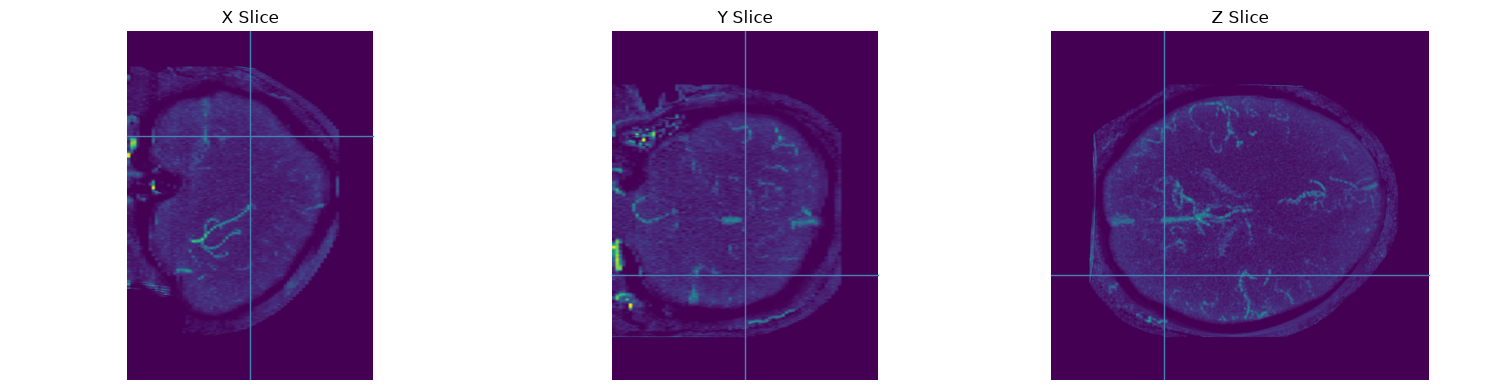

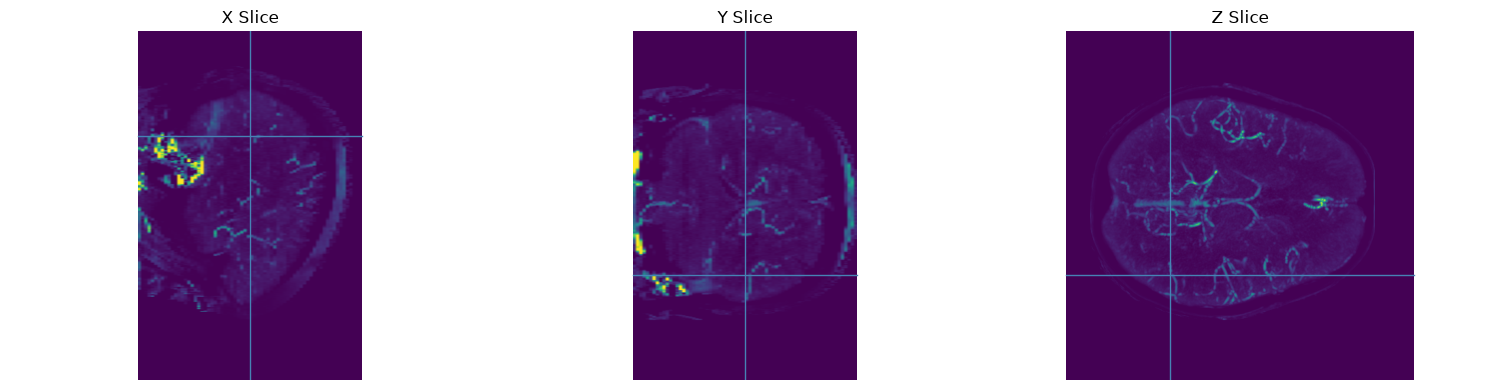

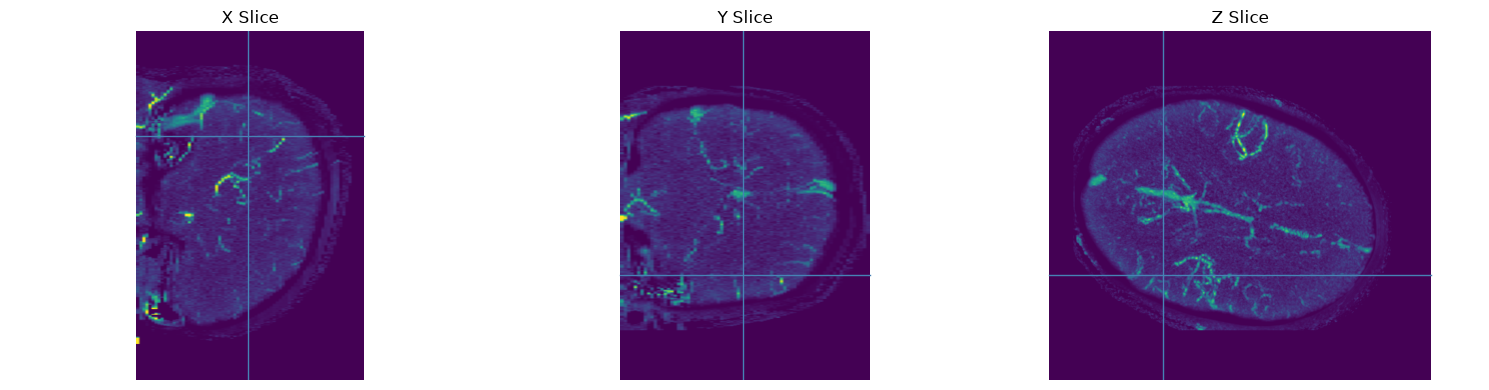

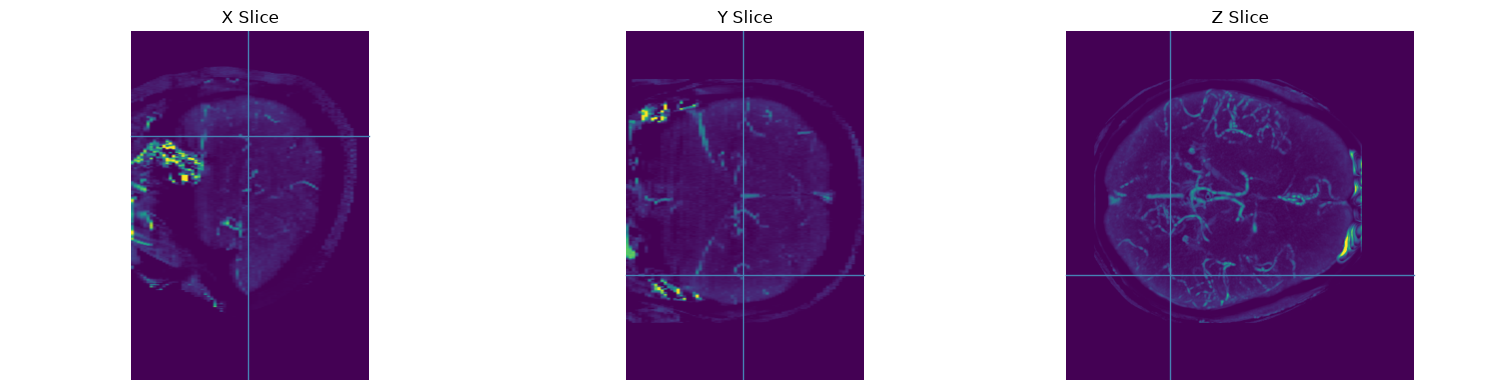

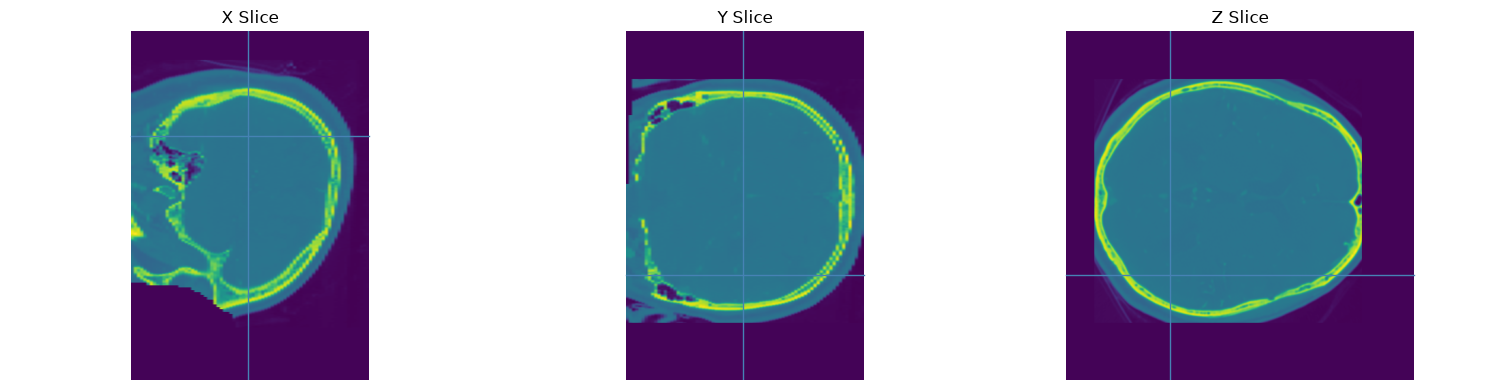

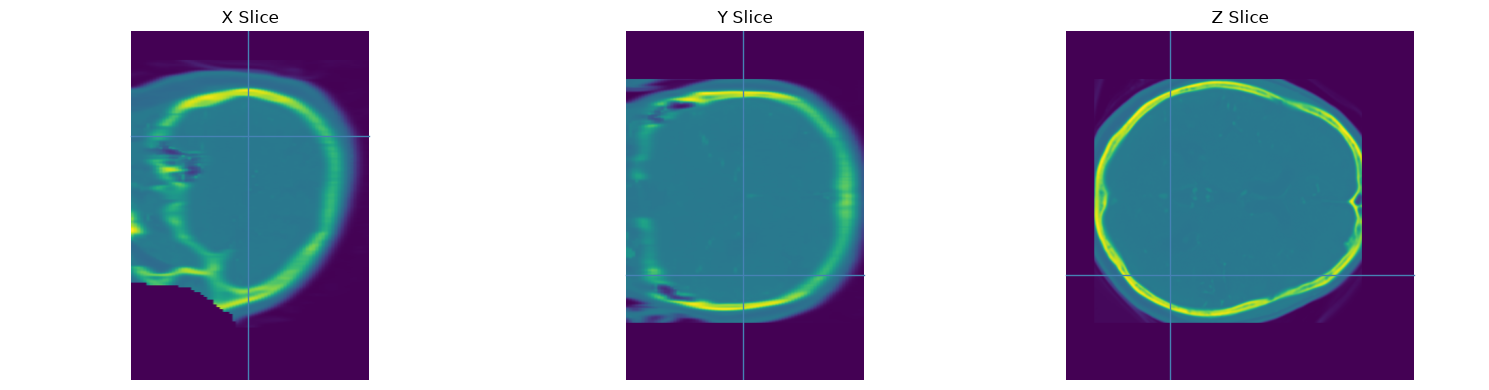

In [1]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import nibabel as nib
import matplotlib.pyplot as plt

data_path = "../../nnUNet_raw/Dataset/"

inputs = os.path.join(data_path, "imagesTr")
outputs = os.path.join(data_path, "labelsTr")
id_to_4digit = lambda id: str(id).zfill(4)
patient_input = lambda id: os.path.join(inputs, f"case_{id_to_4digit(id)}_0000.nii.gz")
patient_output = lambda id: os.path.join(outputs, f"case_{id_to_4digit(id)}_0001.nii.gz")

import sys
sys.path.append("../../")
from data import NiiPoint, BaseTfmLibrary as tfm_base, DataTfmLibrary as tfm_data


for idx in [6,7,8,102,103,105]:
    data_inp = NiiPoint.from_path(patient_input(idx), "cuda")#.apply_tfm(lambda x, affine, header: (x>0) * x)
    data_out = NiiPoint.from_path(patient_output(idx), "cuda")#.apply_tfm(lambda x, affine, header: (x>0) * x)    
    data_vessel = tfm_data.vessel_tfm(data_inp, data_out)
    data_vessel = tfm_data.vessel_normalization_tfm(data_vessel)
    data_vessel.plot_slices((0.7, 0.3, 0.5), (10, 10, 5), vmin=-1.0, vmax=1.0)
    print(data_vessel.data.min().item(), data_vessel.data.max().item())    

# For just one example, show the reconstruction
data_reconstructed = tfm_data.inv_vessel_tfm(
        data_inp, 
        tfm_data.inv_vessel_normalization_tfm(data_vessel)
    )
data_out.plot_slices((0.7, 0.3, 0.5))#, (10, 10, 5))
data_reconstructed.plot_slices((0.7, 0.3, 0.5))#, (10, 10, 5))




<Axes: title={'center': 'Z Slice'}>

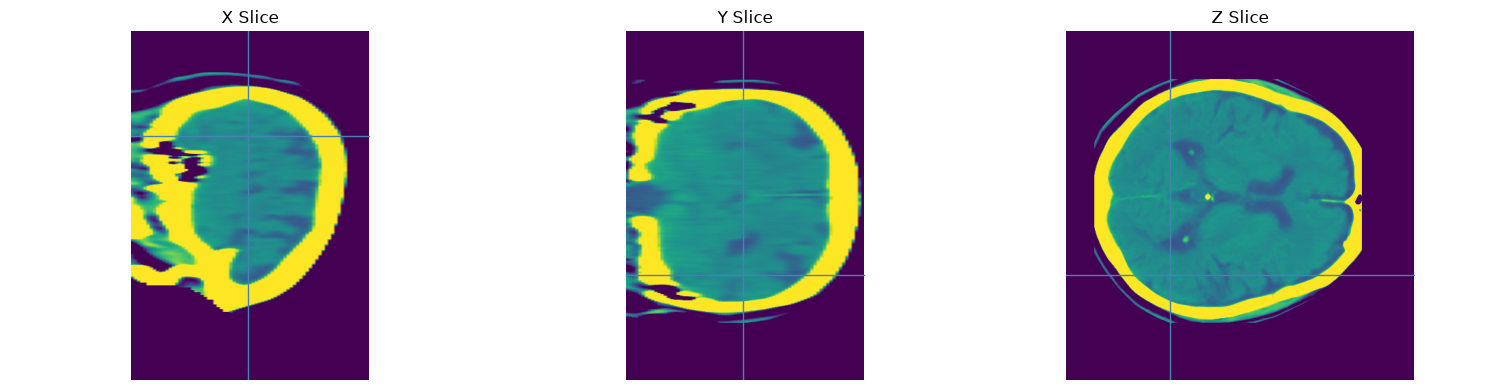

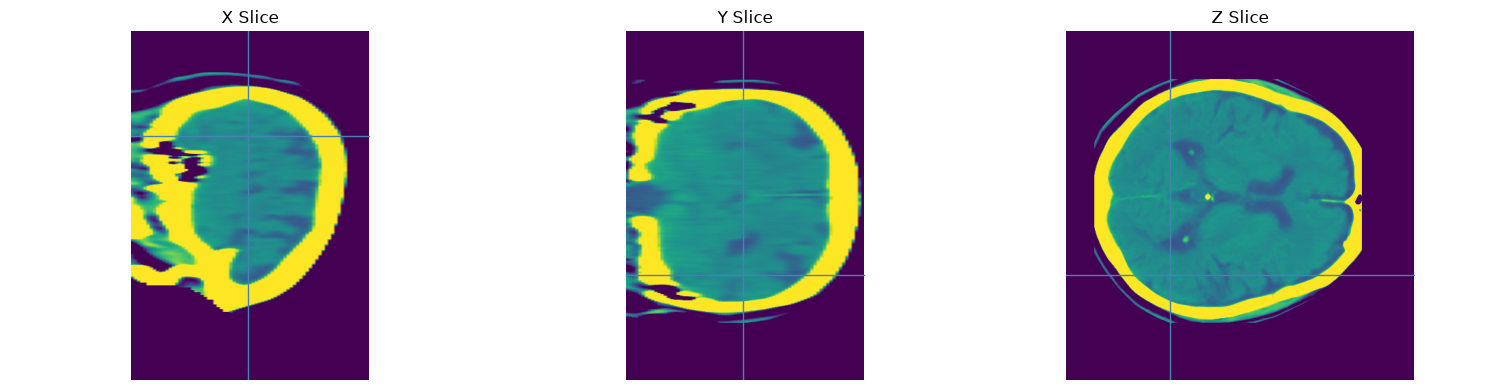

In [2]:
from data import CONSTANTS
data_inp_norm = tfm_data.ncct_normalization_tfm(data_inp)
data_inp_recn = tfm_data.inv_ncct_normalization_tfm(data_inp_norm)


data_inp_recn.plot_slices((0.7, 0.3, 0.5), vmin=CONSTANTS.NCCT_MIN, vmax=CONSTANTS.NCCT_MAX)#, (10, 10, 5))
data_inp.plot_slices((0.7, 0.3, 0.5), vmin=CONSTANTS.NCCT_MIN, vmax=CONSTANTS.NCCT_MAX)#, (10, 10, 5))